# Embedding Layer 테스트

In [2]:
from transformers import AutoTokenizer
from loguru import logger
from model import Encoder, Decoder, Seq2Seq

import torch

In [ ]:
def get_model_from_checkpoint(checkpoint, device):
    embedding_dim = int(checkpoint["embedding_dim"])
    hidden_dim = int(checkpoint["hidden_dim"])
    kor_vocab_size = int(checkpoint["kor_vocab_size"])
    en_vocab_size = int(checkpoint["en_vocab_size"])
    
    encoder = Encoder(kor_vocab_size, embedding_dim, hidden_dim)
    decoder = Decoder(en_vocab_size, embedding_dim, hidden_dim)
    model = Seq2Seq(encoder, decoder, padding_id = int(checkpoint.get("pad_token_id", 0)))
    
    model.load_state_dict(checkpoint["seq2seq_state_dict"], strict = True)
    model.to(device)
    model.eval()
    return model

def load_checkpoint(path, device):
    checkpoint = torch.load(path, map_location = device)
    
    required = ["seq2seq_state_dict", "embedding_dim", "hidden_dim", "kor_vocab_size", "en_vocab_size"]
    missing = [k for k in required if k not in checkpoint]
    
    if missing:
        raise KeyError(f"Missiong keys in checkpoint: {missing}")
    return checkpoint

device = "cuda" if torch.cuda.is_available() else "mps"

kor_tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")
en_tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

model_checkpoint_path = "checkpoints/best.pt"
model = load_checkpoint(model_checkpoint_path, device = device)

logger.info(f"Loaded checkpoint from {model_checkpoint_path}")

model = get_model_from_checkpoint(model, device = device)

embedding_matrix = model.encoder.embedding.weight.detach()
token_id = kor_tokenizer.encode("고양이", add_special_tokens = False)[0]

vec = embedding_matrix[token_id]
sims = torch.cosine_similarity(vec.unsqueeze(0), embedding_matrix)
topk = torch.topk(sims, k = 10)
logger.info(f"'고양이'와 유사한 토큰:\n{kor_tokenizer.convert_ids_to_tokens(topk.indices.tolist())}")

2026-05-08 05:51:08.830 | INFO     | __main__:<module>:34 - Loaded checkpoint from checkpoints/best.pt
2026-05-08 05:51:09.239 | INFO     | __main__:<module>:44 - '고양이'와 유사한 토큰:['고양이', '원가', '담화', '고속도로', '##공원', '기제', '서진', '벤', '냐', '222']


---
# 데이터셋 확인

### 1. Helsinki-NLP/opus-100

In [1]:
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import numpy as np

kor_tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")
en_tokenizer  = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

dataset = load_dataset("Helsinki-NLP/opus-100", "en-ko")

# train + valid + test 전체 합산
all_ko = []
all_en = []

for split in ["train", "validation", "test"]:
    for sample in dataset[split]:
        ko_text = sample["translation"]["ko"]
        en_text = sample["translation"]["en"]
        # 특수 토큰(CLS, SEP) 제외한 실제 내용 토큰 수
        ko_len = len(kor_tokenizer.tokenize(ko_text))
        en_len = len(en_tokenizer.tokenize(en_text))
        all_ko.append(ko_len)
        all_en.append(en_len)

print(f"전체 샘플 수: {len(all_ko):,}")
print(f"\n[한국어] 평균: {np.mean(all_ko):.1f} / 중앙값: {np.median(all_ko):.1f} / 최대: {max(all_ko)} / 최소: {min(all_ko)}")
print(f"[영 어] 평균: {np.mean(all_en):.1f} / 중앙값: {np.median(all_en):.1f} / 최대: {max(all_en)} / 최소: {min(all_en)}")

/root/RNN_Translator/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (913 > 512). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (665 > 512). Running this sequence through the model will result in indexing errors


전체 샘플 수: 1,004,000

[한국어] 평균: 10.9 / 중앙값: 8.0 / 최대: 1911 / 최소: 0
[영 어] 평균: 10.8 / 중앙값: 9.0 / 최대: 665 / 최소: 0


In [16]:
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 157 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (42.1 MB/s)    
debconf: delaying package configuration, since apt-utils is not installed
Selecting previously unselected package fonts-nanum.
(Reading database ... 26294 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
/bin/bash: line 1: fc-cache: command not found


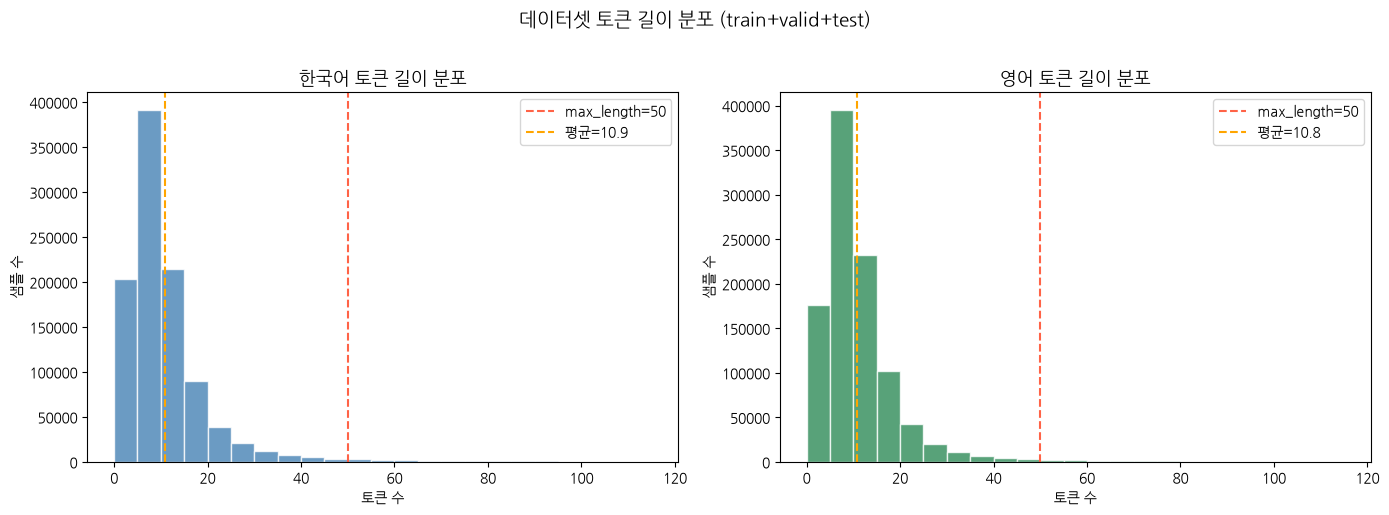


max_length=50 초과 샘플 비율
  한국어: 14,636 / 1,004,000 (1.5%)
  영 어: 9,635 / 1,004,000 (1.0%)


In [ ]:
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = range(0, 120, 5)

# 한국어
axes[0].hist(all_ko, bins=bins, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(50, color="tomato", linestyle="--", linewidth=1.5, label="max_length=50")
axes[0].axvline(np.mean(all_ko), color="orange", linestyle="--", linewidth=1.5, label=f"평균={np.mean(all_ko):.1f}")
axes[0].set_title("한국어 토큰 길이 분포", fontsize=13)
axes[0].set_xlabel("토큰 수")
axes[0].set_ylabel("샘플 수")
axes[0].legend()

# 영어
axes[1].hist(all_en, bins=bins, color="seagreen", alpha=0.8, edgecolor="white")
axes[1].axvline(50, color="tomato", linestyle="--", linewidth=1.5, label="max_length=50")
axes[1].axvline(np.mean(all_en), color="orange", linestyle="--", linewidth=1.5, label=f"평균={np.mean(all_en):.1f}")
axes[1].set_title("영어 토큰 길이 분포", fontsize=13)
axes[1].set_xlabel("토큰 수")
axes[1].set_ylabel("샘플 수")
axes[1].legend()

plt.suptitle("데이터셋 토큰 길이 분포 (train+valid+test)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# max_length=50 초과 비율
ko_over = sum(1 for l in all_ko if l > 50)
en_over = sum(1 for l in all_en if l > 50)
print(f"\nmax_length=50 초과 샘플 비율")
print(f"  한국어: {ko_over:,} / {len(all_ko):,} ({ko_over/len(all_ko)*100:.1f}%)")
print(f"  영 어: {en_over:,} / {len(all_en):,} ({en_over/len(all_en)*100:.1f}%)")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1913 > 512). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (535 > 512). Running this sequence through the model will result in indexing errors


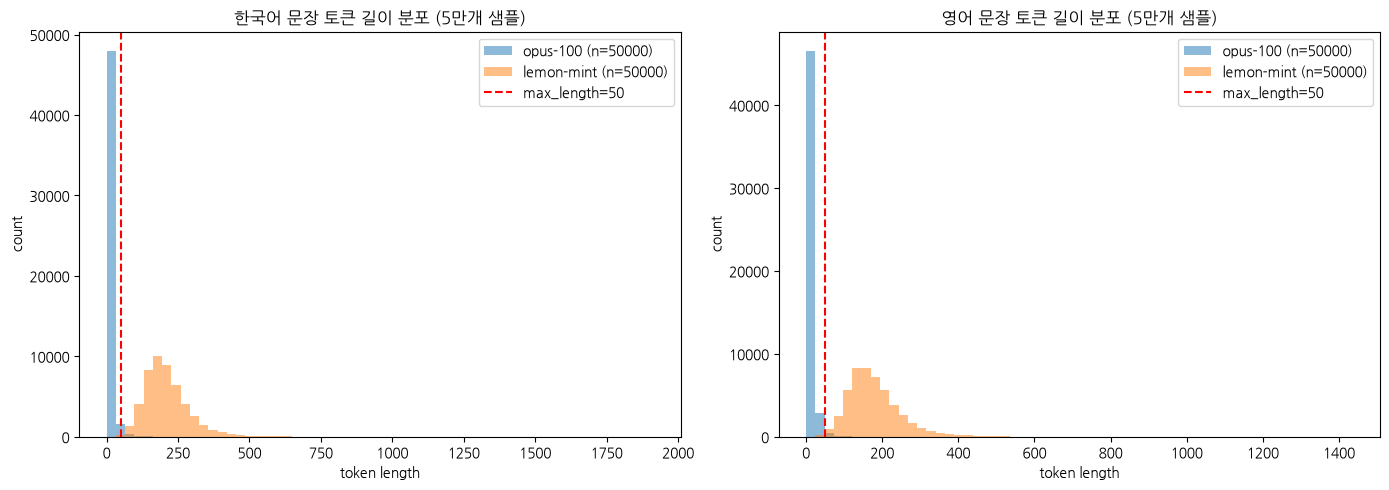

,dataset,n,mean,median,p90,p95,p99,max,pct_over_50
0,opus-100 (ko),50000,13.00736,10.0,22.0,30.0,61.0,1913,1.604
1,opus-100 (en),50000,12.83476,10.0,21.0,28.0,52.0,360,1.096
2,lemon-mint (ko),50000,210.72064,197.0,308.0,354.0,474.0,1755,99.846
3,lemon-mint (en),50000,180.04258,168.0,267.0,310.0,417.0,1436,99.582


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

SAMPLE_SIZE = 50000
SEED = 42

kor_tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")
en_tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

# 1. opus-100 (기존 base 데이터셋, train split) - 5만개 랜덤 샘플링
opus = load_dataset("Helsinki-NLP/opus-100", "en-ko")["train"]
opus = opus.shuffle(seed=SEED).select(range(SAMPLE_SIZE))
opus_translations = opus["translation"]
opus_ko = [t["ko"] for t in opus_translations]
opus_en = [t["en"] for t in opus_translations]

# 2. lemon-mint (증강 데이터셋, train split) - 5만개 랜덤 샘플링
lemon = load_dataset("lemon-mint/korean_english_parallel_wiki_augmented_v1")["train"]
lemon = lemon.shuffle(seed=SEED).select(range(SAMPLE_SIZE))
lemon_ko = lemon["korean"]
lemon_en = lemon["english"]

def token_lengths(texts, tokenizer, batch_size=2000):
    lengths = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(batch, truncation=False, add_special_tokens=True)
        lengths.extend(len(ids) for ids in enc["input_ids"])
    return np.array(lengths)

opus_ko_len = token_lengths(opus_ko, kor_tokenizer)
opus_en_len = token_lengths(opus_en, en_tokenizer)
lemon_ko_len = token_lengths(lemon_ko, kor_tokenizer)
lemon_en_len = token_lengths(lemon_en, en_tokenizer)

# 시각화: opus-100 vs lemon-mint, 언어별
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_hist(ax, opus_vals, lemon_vals, title):
    bins = np.linspace(0, max(opus_vals.max(), lemon_vals.max()), 60)
    ax.hist(opus_vals, bins=bins, alpha=0.5, label=f"opus-100 (n={len(opus_vals)})")
    ax.hist(lemon_vals, bins=bins, alpha=0.5, label=f"lemon-mint (n={len(lemon_vals)})")
    ax.axvline(50, color="red", linestyle="--", label="max_length=50")
    ax.set_title(title)
    ax.set_xlabel("token length")
    ax.set_ylabel("count")
    ax.legend()

plot_hist(axes[0], opus_ko_len, lemon_ko_len, "한국어 문장 토큰 길이 분포 (5만개 샘플)")
plot_hist(axes[1], opus_en_len, lemon_en_len, "영어 문장 토큰 길이 분포 (5만개 샘플)")
plt.tight_layout()
plt.show()

# max_length=50 기준으로 얼마나 잘리는지 정량 확인
def summarize(name, arr):
    return {
        "dataset": name, "n": len(arr),
        "mean": arr.mean(), "median": np.median(arr),
        "p90": np.percentile(arr, 90), "p95": np.percentile(arr, 95), "p99": np.percentile(arr, 99),
        "max": arr.max(), "pct_over_50": (arr > 50).mean() * 100,
    }

summary_df = pd.DataFrame([
    summarize("opus-100 (ko)", opus_ko_len),
    summarize("opus-100 (en)", opus_en_len),
    summarize("lemon-mint (ko)", lemon_ko_len),
    summarize("lemon-mint (en)", lemon_en_len),
])
summary_df

---
### 문장 길이 구간별 성능 시각화

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sacrebleu

from transformers import AutoTokenizer
from utils import load_config
from dataloader import CustomDataLoader
from inference import load_checkpoint, get_model_from_checkpoint

config = load_config("config.yaml")
device = "cuda" if torch.cuda.is_available() else "mps"

kor_tokenizer = AutoTokenizer.from_pretrained(config["model"]["kor_tokenizer"])
en_tokenizer = AutoTokenizer.from_pretrained(config["model"]["en_tokenizer"])

checkpoint = load_checkpoint(config["inference"]["checkpoint_path"], device = device)
model = get_model_from_checkpoint(checkpoint, device = device)

data_loader = CustomDataLoader(
    kor_tokenizer, en_tokenizer,
    max_length = config["inference"]["max_length"],
    batch_size = config["inference"]["batch_size"],
)
_, _, test_dataloader = data_loader.get_data_loader()

sos_token_id = en_tokenizer.cls_token_id
eos_token_id = en_tokenizer.sep_token_id
pad_token_id = en_tokenizer.pad_token_id if en_tokenizer.pad_token_id is not None else eos_token_id
kor_pad_token_id = kor_tokenizer.pad_token_id
max_length = config["inference"]["max_length"]
max_new_tokens = config["inference"]["max_new_token"]

all_yhat, all_ground_truth, all_src_lengths = [], [], []

for src_ids, _, tgt_label in test_dataloader:
    with torch.no_grad():
        src_ids = src_ids.to(device)
        bs = src_ids.size(0)
        src_lengths = (src_ids != kor_pad_token_id).sum(dim = 1)  # 패딩 제외 실제 원문 길이

        _, enc_hidden = model.encoder(src_ids)
        dec_hidden = enc_hidden
        dec_input = torch.full((bs, 1), sos_token_id, dtype = torch.long, device = device)
        generated = dec_input.clone()
        finished = torch.zeros(bs, dtype = torch.bool, device = device)

        for _ in range(max_new_tokens):
            logits, dec_hidden = model.decoder(dec_input, dec_hidden)
            next_ids = torch.argmax(logits[:, -1, :], dim = -1)
            next_ids = torch.where(finished, torch.full_like(next_ids, pad_token_id), next_ids)
            generated = torch.cat([generated, next_ids.unsqueeze(1)], dim = 1)
            finished = finished | (next_ids == eos_token_id)
            if finished.all() or generated.size(1) > max_length:
                break
            dec_input = next_ids.unsqueeze(1)

        for i in range(bs):
            translated = en_tokenizer.decode(generated[i].tolist(), skip_special_tokens = True).strip()
            ground_truth = en_tokenizer.decode(tgt_label[i].tolist(), skip_special_tokens = True).strip()
            all_yhat.append(translated)
            all_ground_truth.append(ground_truth)
            all_src_lengths.append(int(src_lengths[i].item()))

print(f"전체 test 문장 수: {len(all_src_lengths)}, 최대 원문 길이: {max(all_src_lengths)}")

/root/RNN_Translator/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


전체 test 문장 수: 100649, 최대 원문 길이: 400


In [2]:
N_BUCKETS = 5
max_len = max(all_src_lengths)
bin_edges = np.linspace(0, max_len, N_BUCKETS + 1)

length_df = pd.DataFrame({
    "src_length": all_src_lengths,
    "yhat": all_yhat,
    "ground_truth": all_ground_truth,
})
length_df["length_bucket"] = pd.cut(length_df["src_length"], bins = bin_edges, include_lowest = True)

bucket_stats = []
for bucket, group in length_df.groupby("length_bucket", observed = True):
    if len(group) == 0:
        continue
    bucket_bleu = sacrebleu.corpus_bleu(group["yhat"].tolist(), [group["ground_truth"].tolist()])
    bucket_stats.append({"bucket": str(bucket), "n": len(group), "bleu": bucket_bleu.score})

bucket_df = pd.DataFrame(bucket_stats)
bucket_df

,bucket,n,bleu
0,"(-0.001, 80.0]",1391,5.140785
1,"(80.0, 160.0]",25441,5.100631
2,"(160.0, 240.0]",45571,4.518714
3,"(240.0, 320.0]",19611,4.414046
4,"(320.0, 400.0]",8635,4.546408


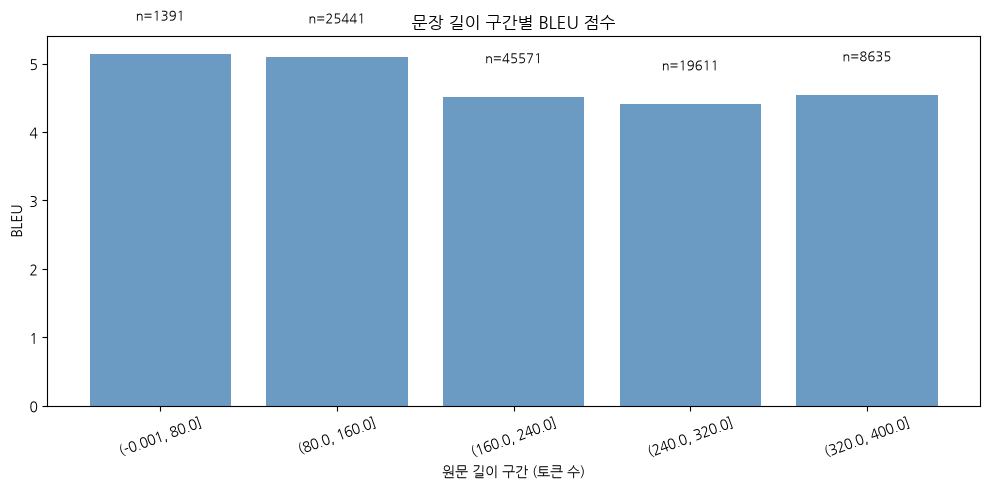

In [3]:
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize = (10, 5))
ax.bar(bucket_df["bucket"], bucket_df["bleu"], color = "steelblue", alpha = 0.8)
ax.set_xlabel("원문 길이 구간 (토큰 수)")
ax.set_ylabel("BLEU")
ax.set_title("문장 길이 구간별 BLEU 점수")

for i, row in bucket_df.iterrows():
    ax.text(i, row["bleu"] + 0.5, f"n={row['n']}", ha = "center", fontsize = 9)

plt.xticks(rotation = 20)
plt.tight_layout()
plt.show()